# bunch of staff

#### create new non-cycling criteria for adata

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np

In [2]:
adata=sc.read_h5ad("/scratch200/reutj/data/updated_cortex_data_hg38.h5ad")

In [23]:
#add non cycling saparation in cellcycle status
adata.obs.CellCycleStatus=adata.obs.CellCycleStatus.astype('str')
adata.obs.loc[(adata.obs.proliferation=="proliferating") & (adata.obs.CellCyclePhase =="Non-cycling"),'CellCycleStatus']="proliferating_non_cycling"
adata.obs.loc[(adata.obs.proliferation!="proliferating") & (adata.obs.CellCyclePhase =="Non-cycling"),'CellCycleStatus']="differentiating_non_cycling"
adata.obs.CellCycleStatus=adata.obs.CellCycleStatus.astype('category')
adata.obs.CellCycleStatus

CellID
10X298_1:TGTGATGGTCCAGCAC    differentiating_non_cycling
10X298_1:ATGCATGGTTAAAGTG      proliferating_non_cycling
10X298_1:TTGGGCGTCACGTAGT    differentiating_non_cycling
10X298_1:TACGCTCTCCCGAGGT    differentiating_non_cycling
10X298_1:TTGCCTGCAAGTTGGG    differentiating_non_cycling
                                        ...             
10X257_2:TAACCAGCAGTAACAA                           SG2M
10X257_1:GGATCTAAGTGGCAGT                           SG2M
10X257_2:GTCAAACTCCTTGACC                           SG2M
10X257_1:CCTAAGAGTCAGATTC                             G1
10X257_1:AATGGAATCGTGTGAT                          PostM
Name: CellCycleStatus, Length: 297927, dtype: category
Categories (5, object): ['G1', 'PostM', 'SG2M', 'differentiating_non_cycling', 'proliferating_non_cycling']

In [24]:
adata.write_h5ad("/scratch200/reutj/data/updated_cortex_data_hg38.h5ad")

In [ ]:
#save genes above 100 in txt file

In [31]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=100)

In [32]:
adata.var

,Chromosome,Accession,Start,End,n_cells
Gene,,,,,
CFAP52,17,ENSG00000166596,9576627,9643459,553
TP73,1,ENSG00000078900,3652520,3736201,2250
LHX1,17,ENSG00000273706,36936785,36944612,6299
CFAP126,1,ENSG00000188931,161364731,161367874,1472
BHMT,5,ENSG00000145692,79111779,79132290,574
...,...,...,...,...,...
AC091117.2,15,ENSG00000259418,45041716,45058707,568
ADORA2A-AS1,22,ENSG00000178803,24429206,24495074,3832
ENTPD4,8,ENSG00000197217,23385783,23457695,60554


In [33]:
ens_list=adata.var["Accession"].tolist()

In [35]:
# Using "with open" syntax to automatically close the file
with open("/scratch200/reutj/data/cortex_ens_above_100.txt", 'w') as file:
    # Join the list elements into a single string with a newline character
    data_to_write = '\n'.join(ens_list)
    # Write the data to the file
    file.write(data_to_write)

<b> I have also done the same with gene names using adata.var_names <b>

#### do the same with the big data

In [12]:
adata_big=sc.read_h5ad("/scratch200/reutj/data/human_dev_GRCh38-3.0.0_all_layers.h5ad")

In [56]:
#get over 100 genes list
sc.pp.filter_cells(adata_big, min_genes=200)
sc.pp.filter_genes(adata_big, min_cells=100)

In [57]:
genes_list=adata_big.var.Gene.to_list()

In [59]:
# Using "with open" syntax to automatically close the file
with open("/scratch200/reutj/data/all_data_genes_above100.txt", 'w') as file:
    # Join the list elements into a single string with a newline character
    data_to_write = '\n'.join(genes_list)
    # Write the data to the file
    file.write(data_to_write)

In [61]:
ens_list=adata_big.var_names.to_list()

In [63]:
# Using "with open" syntax to automatically close the file
with open("/scratch200/reutj/data/all_data_ens_above100.txt", 'w') as file:
    # Join the list elements into a single string with a newline character
    data_to_write = '\n'.join(ens_list)
    # Write the data to the file
    file.write(data_to_write)

In [112]:
adata_big

AnnData object with n_obs × n_vars = 1655848 × 28587
    obs: 'Age', 'CellClass', 'Region', 'Subdivision', 'Subregion', 'Tissue', 'TopLevelCluster', 'organism_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'dissection', 'sample_id', 'cluster_id', 'n_genes'
    var: 'Chromosome', 'End', 'Gene', 'Start', 'Strand', 'n_cells'
    uns: 'batch_condition', 'schema_version', 'title'
    layers: 'ambiguous', 'spliced', 'unspliced'

##### update to have forebrain,nidbrain,hindbrain sections

In [116]:
adata_big.obs.Region.unique().to_list()

["b'Telencephalon'",
 "b'Diencephalon'",
 "b'Midbrain'",
 "b'Forebrain'",
 "b'Cerebellum'",
 "b'Medulla'",
 "b'Pons'",
 "b'Hindbrain'",
 "b'Head'",
 "b'Brain'"]

In [118]:
#add non cycling saparation in cellcycle status
adata_big.obs["region_general"]=adata_big.obs.Region.astype('str')
adata_big.obs.loc[adata_big.obs.Region.isin(["b'Telencephalon'","b'Diencephalon'","b'Forebrain'"]),'region_general']="b'Forebrain_general'"
adata_big.obs.loc[adata_big.obs.Region=="b'Midbrain'",'region_general']="b'Midbrain_general'"
adata_big.obs.loc[adata_big.obs.Region.isin(["b'Cerebellum'","b'Pons'","b'Medulla'","b'Hindbrain'"]),'region_general']="b'hindbrain_general'"
adata_big.obs.region_general=adata_big.obs.region_general.astype('category')
adata_big.obs

,Age,CellClass,Region,Subdivision,Subregion,Tissue,TopLevelCluster,organism_ontology_term_id,disease_ontology_term_id,self_reported_ethnicity_ontology_term_id,assay_ontology_term_id,sex_ontology_term_id,development_stage_ontology_term_id,donor_id,suspension_type,dissection,sample_id,cluster_id,n_genes,region_general
CellID,,,,,,,,,,,,,,,,,,,,
b'10X89_1:ACGAGGAAGAGCCTAG',8.0,b'Erythrocyte',b'Telencephalon',b'Cortex',b'Cortex',b'Cortex',25,NCBITaxon:9606,PATO:0000461,unknown,EFO:0009899,n/a,HsapDv:0000102,b'BRC2006',nucleus,b'Cortex',b'10X89_1',240,262,b'Forebrain_general'
b'10X89_1:ACGCCAGTCGATAGAA',8.0,b'Erythrocyte',b'Telencephalon',b'Cortex',b'Cortex',b'Cortex',25,NCBITaxon:9606,PATO:0000461,unknown,EFO:0009899,n/a,HsapDv:0000102,b'BRC2006',nucleus,b'Cortex',b'10X89_1',236,666,b'Forebrain_general'
b'10X89_1:CTTCTCTAGTCAAGGC',8.0,b'Erythrocyte',b'Telencephalon',b'Cortex',b'Cortex',b'Cortex',25,NCBITaxon:9606,PATO:0000461,unknown,EFO:0009899,n/a,HsapDv:0000102,b'BRC2006',nucleus,b'Cortex',b'10X89_1',235,2050,b'Forebrain_general'
b'10X89_1:GGGCACTAGCGATATA',8.0,b'Erythrocyte',b'Telencephalon',b'Cortex',b'Cortex',b'Cortex',25,NCBITaxon:9606,PATO:0000461,unknown,EFO:0009899,n/a,HsapDv:0000102,b'BRC2006',nucleus,b'Cortex',b'10X89_1',234,952,b'Forebrain_general'
b'10X89_1:TTCTACAAGGTGTGGT',8.0,b'Erythrocyte',b'Telencephalon',b'Cortex',b'Cortex',b'Cortex',25,NCBITaxon:9606,PATO:0000461,unknown,EFO:0009899,n/a,HsapDv:0000102,b'BRC2006',nucleus,b'Cortex',b'10X89_1',234,1408,b'Forebrain_general'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
b'10X302_7:AGAGAATAGAGGATCC',7.0,b'Vascular',b'Midbrain',b'Midbrain',b'Midbrain',b'Midbrain',23,NCBITaxon:9606,PATO:0000461,unknown,EFO:0009922,n/a,HsapDv:0000101,b'XDD:398',nucleus,b'Midbrain',b'10X302_7',255,5784,b'Midbrain_general'
b'10X302_8:AAGCCATTCCACCTCA',7.0,b'Vascular',b'Midbrain',b'Midbrain',b'Midbrain',b'Midbrain',23,NCBITaxon:9606,PATO:0000461,unknown,EFO:0009922,n/a,HsapDv:0000101,b'XDD:398',nucleus,b'Midbrain',b'10X302_8',251,6924,b'Midbrain_general'
b'10X302_8:ACGGTTAGTTAGGCCC',7.0,b'Vascular',b'Midbrain',b'Midbrain',b'Midbrain',b'Midbrain',23,NCBITaxon:9606,PATO:0000461,unknown,EFO:0009922,n/a,HsapDv:0000101,b'XDD:398',nucleus,b'Midbrain',b'10X302_8',251,5413,b'Midbrain_general'


In [121]:
adata_big.write_h5ad("/scratch200/reutj/data/updated_data_all2.h5ad")

In [ ]:
#look on differentiating ges

In [14]:
ges_diff_non=pd.read_csv("/scratch200/reutj/data/spec_tables_new/ges_spec_v3_differentiating_non_cycling.csv")

(0.0, 10.0)

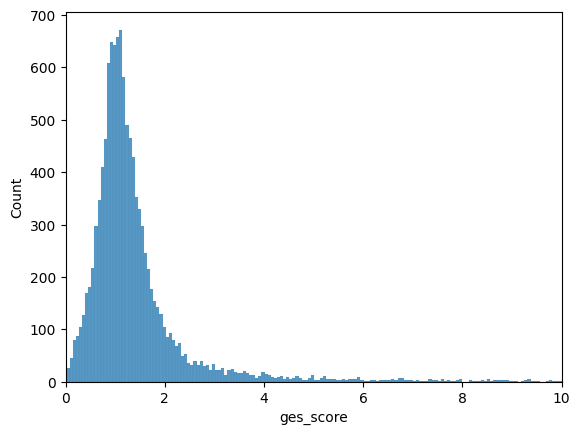

In [20]:
import seaborn as sns

gfg = sns.histplot(ges_diff_non.ges_score)
gfg.set_xlim(0,10)


In [23]:
print(ges_diff_non.shape)
sum(ges_diff_non.ges_score>1)

(11602, 12)


7332

In [24]:
ges_diff_neuroblast=pd.read_csv("/scratch200/reutj/data/spec_tables_new/ges_spec_v3_Neuroblast.csv")

In [25]:
print(ges_diff_neuroblast.shape)
sum(ges_diff_neuroblast.ges_score>1)
#just 73 above 1 so why it bnehaves so weird 

(11252, 11)


73

In [26]:
micro=pd.read_csv("/scratch200/reutj/data/hsg_gene_lists/microcephaly_genes.csv")

In [27]:
micro

,Unnamed: 0,gene,ens
0,0,AARS1,ENSG00000090861
1,1,ACBD6,ENSG00000230124
2,2,ADARB1,ENSG00000197381
3,3,ANKLE2,ENSG00000176915
4,4,AP4E1,ENSG00000081014
...,...,...,...
263,263,TUBGCP3,ENSG00000126216
264,264,WDFY3,ENSG00000163625
265,265,ZNHIT3,ENSG00000273611
266,266,ZPR1,ENSG00000109917


In [29]:
ges_diff_neuroblast[ges_diff_neuroblast.gene.isin(micro.gene.tolist())]

,Unnamed: 0,gene,ges_score,mean_expression_target,mean_expression_other,per_expressed_target,per_expressed_other,per_exp_Radial glia,per_exp_Neuronal IPC,per_exp_Neuron,per_exp_Glioblast
150,14,EOMES,0.771862,0.464521,0.202081,0.421337,0.168646,0.092584,0.923623,0.040297,0.028774
398,221,UNC80,0.586115,0.165887,0.095037,0.280126,0.198412,0.071261,0.245248,0.310914,0.131717
742,4599,NAPB,0.494222,0.186902,0.126985,0.354076,0.285577,0.183269,0.301743,0.383339,0.231573
808,447,ADARB1,0.486190,0.191321,0.132134,0.339009,0.259112,0.112790,0.157397,0.480126,0.090724
858,373,FANCF,0.479092,0.236823,0.165983,0.447282,0.363950,0.357720,0.508890,0.365471,0.262778
...,...,...,...,...,...,...,...,...,...,...,...
11173,6568,CENPF,0.074809,0.105056,0.471545,0.169183,0.399716,0.589290,0.752387,0.132610,0.408422
11195,3573,FANCI,0.066764,0.033611,0.169043,0.070099,0.284056,0.323596,0.616011,0.073262,0.445014
11197,3739,ORC6,0.064022,0.044941,0.235706,0.094017,0.371618,0.510475,0.706403,0.094334,0.506438
11203,1661,GINS2,0.061171,0.061209,0.335995,0.127361,0.452328,0.641536,0.613208,0.148544,0.689003


In [30]:
ges_diff_non[ges_diff_non.gene.isin(micro.gene.tolist())]

,Unnamed: 0,gene,ges_score,mean_expression_target,mean_expression_other,per_expressed_target,per_expressed_other,per_exp_proliferating_non_cycling,per_exp_PostM,per_exp_S,per_exp_G1,per_exp_G2M
63,772,CAMK2B,23.432832,0.098179,0.004900,0.215989,0.011699,0.010433,0.009629,0.013287,0.013014,0.008625
456,479,ADARB1,5.331309,0.229636,0.050377,0.417911,0.116958,0.081633,0.107978,0.158962,0.107257,0.136174
530,10266,PCLO,4.661997,0.818471,0.205334,0.810870,0.349399,0.286171,0.297937,0.440761,0.350558,0.314428
566,1251,DPP6,4.352311,0.636356,0.171005,0.692045,0.286204,0.241700,0.239065,0.310727,0.321259,0.292995
571,4235,ZEB2,4.331214,1.104614,0.298284,0.837980,0.476527,0.495355,0.405777,0.501730,0.442557,0.589650
...,...,...,...,...,...,...,...,...,...,...,...,...
11485,3785,TRIP13,0.180545,0.019569,0.126766,0.050772,0.282187,0.039826,0.171664,0.508858,0.263624,0.543649
11540,3745,FANCI,0.135686,0.029919,0.257897,0.068856,0.419062,0.087572,0.235626,0.721246,0.477048,0.527705
11549,1743,GINS2,0.126063,0.055431,0.514274,0.134877,0.646381,0.374657,0.518294,0.790035,0.902231,0.236801
11552,3917,ORC6,0.121768,0.037806,0.363127,0.090848,0.548603,0.143695,0.344429,0.836817,0.667393,0.753528


In [ ]:
#vs ipc

In [31]:
ipc_ges=pd.read_csv("/scratch200/reutj/data/spec_tables_new/ges_spec_v3_IPC.csv")
print(ipc_ges.shape)
sum(ipc_ges.ges_score>1)
#just 4 above 1 so why it may explain why it behab=ves so weird

(12021, 11)


4

In [32]:
ipc_ges[ipc_ges.gene.isin(micro.gene.tolist())]

,Unnamed: 0,gene,ges_score,mean_expression_target,mean_expression_other,per_expressed_target,per_expressed_other,per_exp_Neuroblast,per_exp_Radial glia,per_exp_Neuron,per_exp_Glioblast
9,13,EOMES,0.819559,1.245271,0.163134,0.923623,0.157929,0.421337,0.092584,0.040297,0.028774
13,5741,WDR62,0.760242,0.147704,0.020859,0.345450,0.050621,0.010506,0.113720,0.008487,0.113126
18,11156,CEP55,0.652083,0.266342,0.043853,0.465271,0.080168,0.008311,0.229450,0.007043,0.122783
26,5355,CIT,0.576548,0.406101,0.075624,0.553123,0.123849,0.040776,0.257433,0.030338,0.262383
34,4672,KNL1,0.555461,0.571726,0.110508,0.638784,0.147810,0.056653,0.320508,0.022400,0.305610
...,...,...,...,...,...,...,...,...,...,...,...
11715,4613,MYCN,0.043116,0.108731,0.270753,0.268459,0.488306,0.363636,0.569828,0.510406,0.536526
11754,454,ADARB1,0.041443,0.060340,0.156318,0.157397,0.292273,0.339009,0.112790,0.480126,0.090724
11770,7117,FILIP1,0.040410,0.038714,0.102856,0.096435,0.181890,0.033580,0.429092,0.024016,0.393181
11855,10659,PCLO,0.034482,0.184230,0.573617,0.338968,0.625998,0.668457,0.375767,0.925670,0.303180


In [33]:
ges_ipc_new=pd.read_csv("/scratch200/reutj/notebooks/ges_spec_v3_IPC.csv")

In [34]:
print(ges_ipc_new.shape)
sum(ges_ipc_new.ges_score>1)

(12021, 11)


6691

(0.0, 10.0)

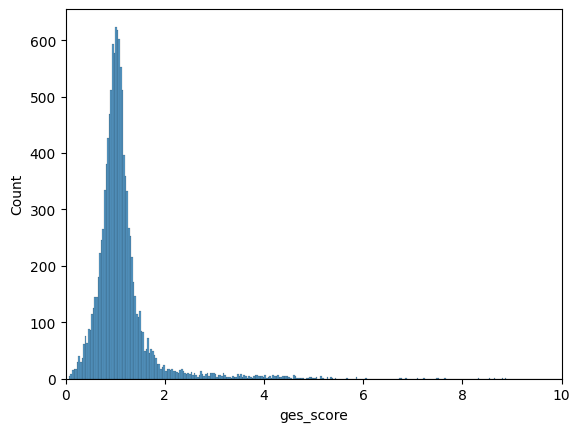

In [35]:
gfg = sns.histplot(ges_ipc_new.ges_score)
gfg.set_xlim(0,10)

In [2]:
with open("/scratch200/reutj/data/hsg_gene_lists/autism_strong.gmt") as f:
...     for _ in range(5):
...             print(f.readline().strip().split("\t"))


['strong_autism_genes', 'Description', 'ABCE1', 'ACTB', 'ADNP', 'ADSL', 'AFF2', 'AHDC1', 'ALDH5A1', 'ANK2', 'ANK3', 'ANKRD11', 'ANP32A', 'AP2S1', 'ARF3', 'ARHGEF9', 'ARID1B', 'ARX', 'ASH1L', 'ASXL3', 'ATRX', 'AUTS2', 'BAZ2B', 'BCKDK', 'BCL11A', 'BRAF', 'BRSK2', 'CACNA1A', 'CACNA1C', 'CACNA1E', 'CACNA2D3', 'CAMTA2', 'CAPRIN1', 'CASK', 'CASZ1', 'CDKL5', 'CELF4', 'CHAMP1', 'CHD2', 'CHD3', 'CHD7', 'CHD8', 'CIC', 'CNOT3', 'CORO1A', 'CPSF7', 'CREBBP', 'CSDE1', 'CSNK2A1', 'CTCF', 'CTNNB1', 'CUL3', 'DDX3X', 'DEAF1', 'DHCR7', 'DIP2A', 'DLG4', 'DMPK', 'DNMT3A', 'DPYSL2', 'DSCAM', 'DYNC1H1', 'DYRK1A', 'EBF3', 'EHMT1', 'EIF3G', 'ELAVL3', 'EP300', 'FMR1', 'FOXG1', 'FOXP1', 'FOXP2', 'GABRB2', 'GABRB3', 'GFAP', 'GIGYF1', 'GIGYF2', 'GNAI1', 'GRIA2', 'GRIN1', 'GRIN2A', 'GRIN2B', 'HDLBP', 'HECTD4', 'HIVEP2', 'HNRNPH2', 'HNRNPU', 'HRAS', 'IQSEC2', 'IRF2BPL', 'KANSL1', 'KATNAL2', 'KCNB1', 'KCNQ3', 'KDM2B', 'KDM3B', 'KDM5B', 'KDM5C', 'KDM6B', 'KIAA0232', 'KLHL20', 'KMT2A', 'KMT2C', 'KMT2E', 'KMT5B', 'LDB1'

In [13]:
with open("/scratch200/reutj/data/hsg_gene_lists/id_list_updated.gmt") as f:
...     for _ in range(5):
...             print(f.readline().strip().split("\t"))


['id_genes', 'Description', 'AAAS', 'AARS1', 'AASS', 'ABAT', 'ABCA2', 'ABCC9', 'ABCD1', 'ABCD4', 'ABHD16A', 'ABHD5', 'ACACA', 'ACAD9', 'ACADM', 'ACADS', 'ACBD6', 'ACER3', 'ACO2', 'ACOX1', 'ACSL4', 'ACTB', 'ACTG1', 'ACTL6A', 'ACTL6B', 'ACY1', 'ADAM22', 'ADAR', 'ADARB1', 'ADAT3', 'ADD1', 'ADD3', 'ADGRG1', 'ADGRL1', 'ADK', 'ADNP', 'ADSL', 'AFF2', 'AFF3', 'AFF4', 'AGA', 'AGO1', 'AGO2', 'AGTPBP1', 'AHCY', 'AHDC1', 'AHI1', 'AIFM1', 'AIMP1', 'AKT3', 'ALDH18A1', 'ALDH3A2', 'ALDH4A1', 'ALDH5A1', 'ALDH7A1', 'ALG1', 'ALG11', 'ALG12', 'ALG13', 'ALG3', 'ALG6', 'ALG8', 'ALG9', 'ALKBH8', 'ALMS1', 'AMER1', 'AMPD2', 'AMT', 'ANK2', 'ANK3', 'ANKRD11', 'ANKRD17', 'ANO4', 'AP1G1', 'AP1S1', 'AP1S2', 'AP2M1', 'AP3B1', 'AP3B2', 'AP4B1', 'AP4E1', 'AP4M1', 'AP4S1', 'APC2', 'COA8', 'ARCN1', 'ARF1', 'ARF3', 'ARFGEF1', 'ARFGEF2', 'ARG1', 'ARHGEF9', 'ARID1A', 'ARID1B', 'ARID2', 'ARL13B', 'ARL6', 'ARMC9', 'ARSA', 'ARSB', 'ARSL', 'ARV1', 'ARX', 'ASAH1', 'ASH1L', 'ASL', 'ASNS', 'ASPA', 'ASPM', 'ASS1', 'ASXL1', 'ASXL2'

##### fix corupted gmt files

In [18]:
updated_hsg=pd.read_csv("/scratch200/reutj/data/hsg_gene_lists/updated_hsg_list.csv")
output_file="/scratch200/reutj/data/hsg_gene_lists/updated_hsg_list.gmt"
with open(output_file, 'w') as f:
    # Create a line in GMT format for one gene set
    line = f"updated_hsg_genes\tDescription\t{'\t'.join(updated_hsg.gene.tolist())}\n"
    f.write(line)

In [27]:
updated_har=pd.read_csv("/scratch200/reutj/data/hsg_gene_lists/updated_har_list.csv")
output_file="/scratch200/reutj/data/hsg_gene_lists/updated_har_list.gmt"
with open(output_file, 'w') as f:
    # Create a line in GMT format for one gene set
    line = f"updated_har_genes\tDescription\t{'\t'.join(updated_har.gene[:1511].tolist())}\n"
    f.write(line)

In [28]:
updated_har_nsc=pd.read_csv("/scratch200/reutj/data/hsg_gene_lists/har_genes_nsc_df.csv")
output_file="/scratch200/reutj/data/hsg_gene_lists/har_genes_nsc_df.gmt"
with open(output_file, 'w') as f:
    # Create a line in GMT format for one gene set
    line = f"har_genes_nsc_df\tDescription\t{'\t'.join(updated_har_nsc.gene.tolist())}\n"
    f.write(line)

In [29]:
updated_har_neurons=pd.read_csv("/scratch200/reutj/data/hsg_gene_lists/har_genes_neurons_df.csv")
output_file="/scratch200/reutj/data/hsg_gene_lists/har_genes_neurons_df.gmt"
with open(output_file, 'w') as f:
    # Create a line in GMT format for one gene set
    line = f"har_genes_neurons_df\tDescription\t{'\t'.join(updated_har_neurons.gene.tolist())}\n"
    f.write(line)

#### create gsea plot

In [3]:
ges=pd.read_csv("/scratch200/reutj/data/spec_tables_new/ges_spec_v3_Neuron.csv")

In [4]:
ges_scores_en=ges.ges_score
ges_scores_en.index=ges.gene

In [5]:
import gseapy as gp

In [6]:
gsea_res = gp.prerank(rnk=ges_scores_en,
               gene_sets="/scratch200/reutj/data/hsg_gene_lists/dup_genes_list.gmt",  # Output directory
               min_size=5,
               max_size=2500,
               seed=6,
               permutation_type='geneset',
               permutation_num=10000,
               format='pdf')

In [7]:
import matplotlib.pyplot as plt

In [9]:
term=gsea_res.res2d.Term[0]

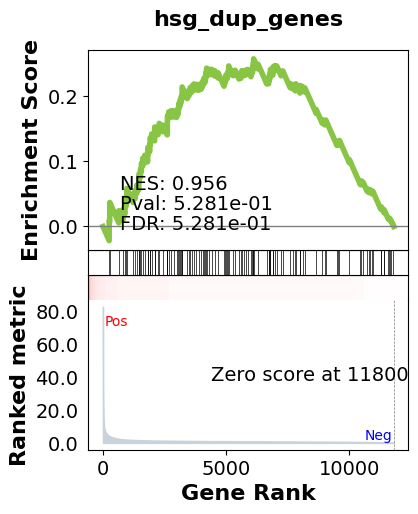

In [11]:
gsea_res.plot(term)
plt.savefig("gsea_plot.png", dpi=300, bbox_inches='tight')

#### fix ges_scores annotaions
in the last ges_files that were created gene annotations are in ensg and not gene scores
lets fix that.. 


In [14]:
ens_adata=adata_big.var_names.to_list()
gene_sym_adata=adata_big.var["Gene"].to_list()

In [15]:
ges_forbrain=pd.read_csv("/scratch200/reutj/data/spec_tables_new/ges_spec_big_Forebrain_general.csv")
ges_midbrain=pd.read_csv("/scratch200/reutj/data/spec_tables_new/ges_spec_big_Midbrain_general.csv")
ges_hindbrain=pd.read_csv("/scratch200/reutj/data/spec_tables_new/ges_spec_big_hindbrain_general.csv")

In [27]:
ges_forbrain=ges_forbrain.rename(columns={'gene':'ens'})
ges_midbrain=ges_midbrain.rename(columns={'gene':'ens'})
ges_hindbrain=ges_hindbrain.rename(columns={'gene':'ens'})

In [30]:
#add gene names based on the matching index of the ens in adata
ges_forbrain['gene']=[gene_sym_adata[ens_adata.index(ens)] for ens in ges_forbrain.ens]
ges_midbrain['gene']=[gene_sym_adata[ens_adata.index(ens)] for ens in ges_midbrain.ens]
ges_hindbrain['gene']=[gene_sym_adata[ens_adata.index(ens)] for ens in ges_hindbrain.ens]

In [ ]:
#save back to csv

In [31]:
ges_forbrain.to_csv("/scratch200/reutj/data/spec_tables_new/ges_spec_big_Forebrain_general.csv")
ges_midbrain.to_csv("/scratch200/reutj/data/spec_tables_new/ges_spec_big_Midbrain_general.csv")
ges_hindbrain.to_csv("/scratch200/reutj/data/spec_tables_new/ges_spec_big_hindbrain_general.csv")